=== Data Shape ===
(20631, 27)

=== Missing Values Check ===
Total Missing: 0

=== Constant Features (Variance = 0) ===
['setting_3', 's_1', 's_10', 's_18', 's_19']


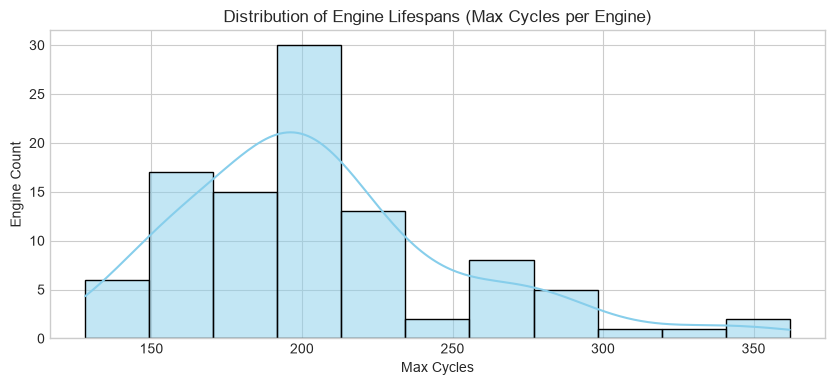


Shortest Lifespan: 128 cycles
Longest Lifespan: 362 cycles
Average Lifespan: 206.31 cycles


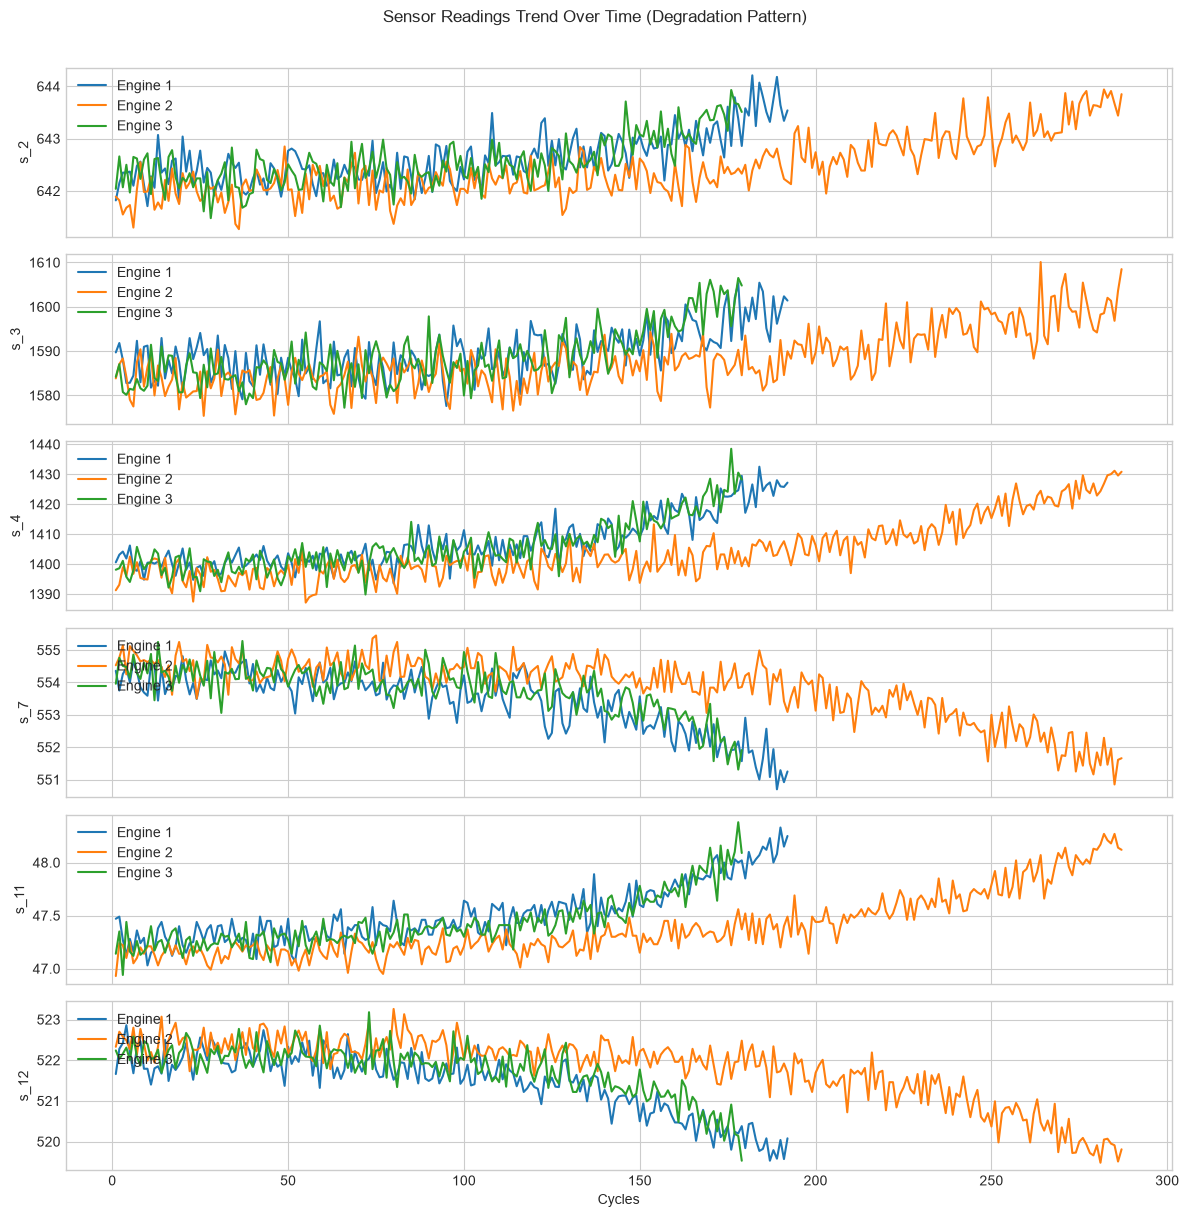

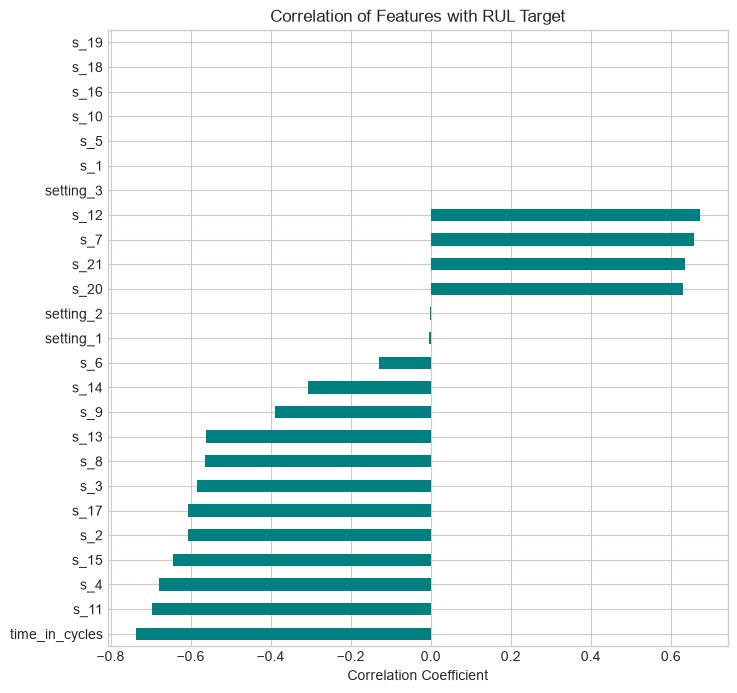

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# إعدادات الرسم
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)

# 1. تعريف الأسماء وقراءة الداتا
columns = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
train_df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=columns)

# 2. حساب الـ RUL

max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index().rename(columns={'time_in_cycles': 'max_cycle'})
train_df = train_df.merge(max_cycles, on='unit_number').assign(RUL=lambda x: x['max_cycle'] - x['time_in_cycles']).drop(columns=['max_cycle'])

# ==========================================
# A. نظرة عامة واستكشاف القيم المفقودة والثابتة
# ==========================================
print("=== Data Shape ===")
print(train_df.shape)

print("\n=== Missing Values Check ===")
print(f"Total Missing: {train_df.isnull().sum().sum()}")

# فحص الحساسات الثابتة (Sensors with zero variance / Constant columns)
# الحساسات دي مش بتعبر عن تدهور وبالتالي ملهاش قيمة في الـ Training
std_series = train_df.drop(columns=['unit_number', 'time_in_cycles', 'RUL']).std()
constant_features = std_series[std_series == 0].index.tolist()
print(f"\n=== Constant Features (Variance = 0) ===")
print(constant_features)

# ==========================================
# B. توزيع دورات حياة المحركات (Engine Lifespan)
# ==========================================
engine_lifespans = train_df.groupby('unit_number')['time_in_cycles'].max()

plt.figure(figsize=(10, 4))
sns.histplot(engine_lifespans, kde=True, color='skyblue')
plt.title('Distribution of Engine Lifespans (Max Cycles per Engine)')
plt.xlabel('Max Cycles')
plt.ylabel('Engine Count')
plt.show()

print(f"\nShortest Lifespan: {engine_lifespans.min()} cycles")
print(f"Longest Lifespan: {engine_lifespans.max()} cycles")
print(f"Average Lifespan: {engine_lifespans.mean():.2f} cycles")

# ==========================================
# C. سلوك الحساسات مع تدهور المحرك عبر الزمن
# ==========================================
# لرسم تدهور بعض الحساسات لأول 3 محركات
sample_units = [1, 2, 3]
sensors_to_plot = ['s_2', 's_3', 's_4', 's_7', 's_11', 's_12']

fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(12, 12), sharex=True)

for ax, sensor in zip(axes, sensors_to_plot):
    for unit in sample_units:
        unit_data = train_df[train_df['unit_number'] == unit]
        ax.plot(unit_data['time_in_cycles'], unit_data[sensor], label=f'Engine {unit}')
    ax.set_ylabel(sensor)
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Cycles')
plt.suptitle('Sensor Readings Trend Over Time (Degradation Pattern)', y=1.01)
plt.tight_layout()
plt.show()

# ==========================================
# D. تحليل الارتباط مع الـ Target (RUL Correlation)
# ==========================================
correlations = train_df.drop(columns=['unit_number']).corr()['RUL'].sort_values()

plt.figure(figsize=(8, 8))
correlations.drop('RUL').plot(kind='barh', color='teal')
plt.title('Correlation of Features with RUL Target')
plt.xlabel('Correlation Coefficient')
plt.show()

In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# 1. قراءة الداتا
columns = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]
train_df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=columns)
test_df = pd.read_csv('../data/raw/test_FD001.txt', sep=r'\s+', header=None, names=columns)
rul_true = pd.read_csv('../data/raw/RUL_FD001.txt', header=None, names=['RUL_at_end'])

# معرفة عدد القيم الفريدة في كل عمود
# معرفة عدد القيم الفريدة في كل عمود
x_train=train_df.nunique()

for i,val in enumerate(x_train) :
    if val ==1 :
        name=columns[i]
        train_df=train_df.drop(name,axis=1)


print(train_df.columns)
# 1. تجهيز جدول الـ max_val مع إعادة تسمية العمود عشان يوضح معناه
group = train_df.groupby("unit_number")["time_in_cycles"].max().reset_index()
print(group)
group.rename(columns={'time_in_cycles': 'max_cycle'}, inplace=True)
print(group)
# 2. عمل الـ Merge الصح بـ صراحة (Explicit On)
train_df = train_df.merge(group, on='unit_number', how='left')

# 3. حساب الـ Y (RUL) مباشرة
train_df['Y'] = train_df['max_cycle'] - train_df['time_in_cycles']


Index(['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 's_2', 's_3',
       's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14',
       's_15', 's_17', 's_20', 's_21'],
      dtype='str')
    unit_number  time_in_cycles
0             1             192
1             2             287
2             3             179
3             4             189
4             5             269
..          ...             ...
95           96             336
96           97             202
97           98             156
98           99             185
99          100             200

[100 rows x 2 columns]
    unit_number  max_cycle
0             1        192
1             2        287
2             3        179
3             4        189
4             5        269
..          ...        ...
95           96        336
96           97        202
97           98        156
98           99        185
99          100        200

[100 rows x 2 columns]


In [51]:
import os
import json
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# ==============================================================================
# 1. إعداد المسارات وأسماء الأعمدة
# ==============================================================================
RAW_DATA_PATH = '../data/raw'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

COLUMNS = ['unit_number', 'time_in_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f's_{i}' for i in range(1, 22)]

# ==============================================================================
# 2. قراءة البيانات الأولية (Train & Test & True RUL)
# ==============================================================================
train_df = pd.read_csv(f'{RAW_DATA_PATH}/train_FD001.txt', sep=r'\s+', header=None, names=COLUMNS)
test_df = pd.read_csv(f'{RAW_DATA_PATH}/test_FD001.txt', sep=r'\s+', header=None, names=COLUMNS)
rul_true = pd.read_csv(f'{RAW_DATA_PATH}/RUL_FD001.txt', header=None, names=['RUL_at_end'])

# ==============================================================================
# 3. حذف الأعمدة الثابتة (Constant Columns Drop)
# ==============================================================================
constant_cols = [col for col in train_df.columns if train_df[col].nunique() == 1]
train_df.drop(columns=constant_cols, inplace=True)
test_df.drop(columns=constant_cols, inplace=True)
print(f"[+] Constant Columns Dropped: {constant_cols}")

# ==============================================================================
# 4. دالة الـ Feature Engineering (Rolling Statistics & Lags)
# ==============================================================================
def create_features(df, window_size=10):
    df_feat = df.copy()
    sensor_cols = [c for c in df_feat.columns if c.startswith('s_') or c.startswith('setting_')]
    
    # 1. Rolling Mean, Standard Deviation, and Lag Features
    for col in sensor_cols:
        df_feat[f'{col}_roll_mean'] = df_feat.groupby('unit_number')[col].transform(lambda x: x.rolling(window_size, min_periods=1).mean())
        df_feat[f'{col}_roll_std'] = df_feat.groupby('unit_number')[col].transform(lambda x: x.rolling(window_size, min_periods=1).std()).fillna(0)
        # التعديل: استخدام bfill() مع الـ groupby لضمان المعالجة الصحيحة لكل محرك
        df_feat[f'{col}_lag_1'] = df_feat.groupby('unit_number')[col].shift(1)
        df_feat[f'{col}_lag_1'] = df_feat.groupby('unit_number')[f'{col}_lag_1'].bfill()
        
    return df_feat

print("[+] Applying Feature Engineering (Rolling & Lag Features)...")
train_df = create_features(train_df, window_size=10)
test_df = create_features(test_df, window_size=10)

# ==============================================================================
# 5. حساب الـ Target (Y / RUL) وتطبيق الـ Clipping على Train
# ==============================================================================
group = train_df.groupby("unit_number")["time_in_cycles"].max().reset_index()
group.rename(columns={'time_in_cycles': 'max_cycle'}, inplace=True)

train_df = train_df.merge(group, on='unit_number', how='left')
train_df['Y'] = train_df['max_cycle'] - train_df['time_in_cycles']
train_df.drop(columns=['max_cycle'], inplace=True)

# RUL Clipping عند 125
train_df['Y'] = train_df['Y'].clip(upper=125)

# ==============================================================================
# 6. تجهيز الـ Train & Test Features (X_train, y_train, X_test, y_test)
# ==============================================================================
features = [col for col in train_df.columns if col not in ['unit_number', 'time_in_cycles', 'Y']]

X_train = train_df[features]
y_train = train_df['Y']

# تجهيز الـ Test Set: استخراج آخر دورة فقط لكل محرك وطرح الـ RUL الحقيقي
rul_true['unit_number'] = rul_true.index + 1
test_last_cycle = test_df.groupby('unit_number').last().reset_index()
test_merged = test_last_cycle.merge(rul_true, on='unit_number', how='left')

X_test = test_merged[features]
y_test = test_merged['RUL_at_end'].clip(upper=125)  # تطبيق نفس الـ Clipping على التست لتكافؤ التقييم

# ==============================================================================
# 7. Scaling والتدريب (Model Training)
# ==============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("[+] Training Production XGBoost Regressor...")
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train_scaled, y_train)

# ==============================================================================
# 8. التقييم الشامل (Evaluation on Train & Test Sets)
# ==============================================================================
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n==================================================")
print("       PRODUCTION EVALUATION REPORT (NASA CMAPSS) ")
print("==================================================")
print(f"Train RMSE      : {train_rmse:.2f} cycles")
print(f"Train R2        : {train_r2:.2f}")
print("--------------------------------------------------")
print(f"Test RMSE (UNSEEN) : {test_rmse:.2f} cycles  <-- (المعيار الفعلي)")
print(f"Test MAE (UNSEEN)  : {test_mae:.2f} cycles")
print(f"Test R2 (UNSEEN)   : {test_r2:.2f}")
print("==================================================")

# ==============================================================================
# 9. حفظ ملفات الـ Production (Model & Scaler Exporting)
# ==============================================================================
joblib.dump(model, f'{MODELS_DIR}/xgb_rul_model.joblib')
joblib.dump(scaler, f'{MODELS_DIR}/scaler.joblib')

with open(f'{MODELS_DIR}/features.json', 'w') as f:
    json.dump(features, f)

print(f"\n[✓] Successfully saved artifacts to '{MODELS_DIR}/':")
print("    - xgb_rul_model.joblib")
print("    - scaler.joblib")
print("    - features.json")

[+] Constant Columns Dropped: ['setting_3', 's_1', 's_5', 's_10', 's_16', 's_18', 's_19']
[+] Applying Feature Engineering (Rolling & Lag Features)...
[+] Training Production XGBoost Regressor...

       PRODUCTION EVALUATION REPORT (NASA CMAPSS) 
Train RMSE      : 14.36 cycles
Train R2        : 0.88
--------------------------------------------------
Test RMSE (UNSEEN) : 18.41 cycles  <-- (المعيار الفعلي)
Test MAE (UNSEEN)  : 12.97 cycles
Test R2 (UNSEEN)   : 0.79

[✓] Successfully saved artifacts to '../models/':
    - xgb_rul_model.joblib
    - scaler.joblib
    - features.json
